# Capstone Function 7
You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 

Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.

 Input | Output | Goal |
|-------|--------|------|
| 6D Array (30, 6) | 1D Array (30, ) | Maximise |

## Initial Submission

Bayesian Optimization for 6D ML model hyperparameter tuning (learning rate, regularization, layers, etc.).

### Step 1: Setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("Setup complete!")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete!


### Step 2: Load Data & Initial Analysis

In [2]:
X_init = np.load('../../data/f7/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f7/updated_outputs - Week 4.npy')
hyperparam_names = ['Learning Rate', 'Reg Strength', 'Layers', 'Dropout', 'Batch Size', 'Optimizer']
print(f"6D ML Hyperparameter Data: {X_init.shape}")
print(f"Best performance: {y_init.max():.6f}")
print(f"Output range: [{y_init.min():.6f}, {y_init.max():.6f}]")

6D ML Hyperparameter Data: (30, 6)
Best performance: 1.364968
Output range: [0.002701, 1.364968]


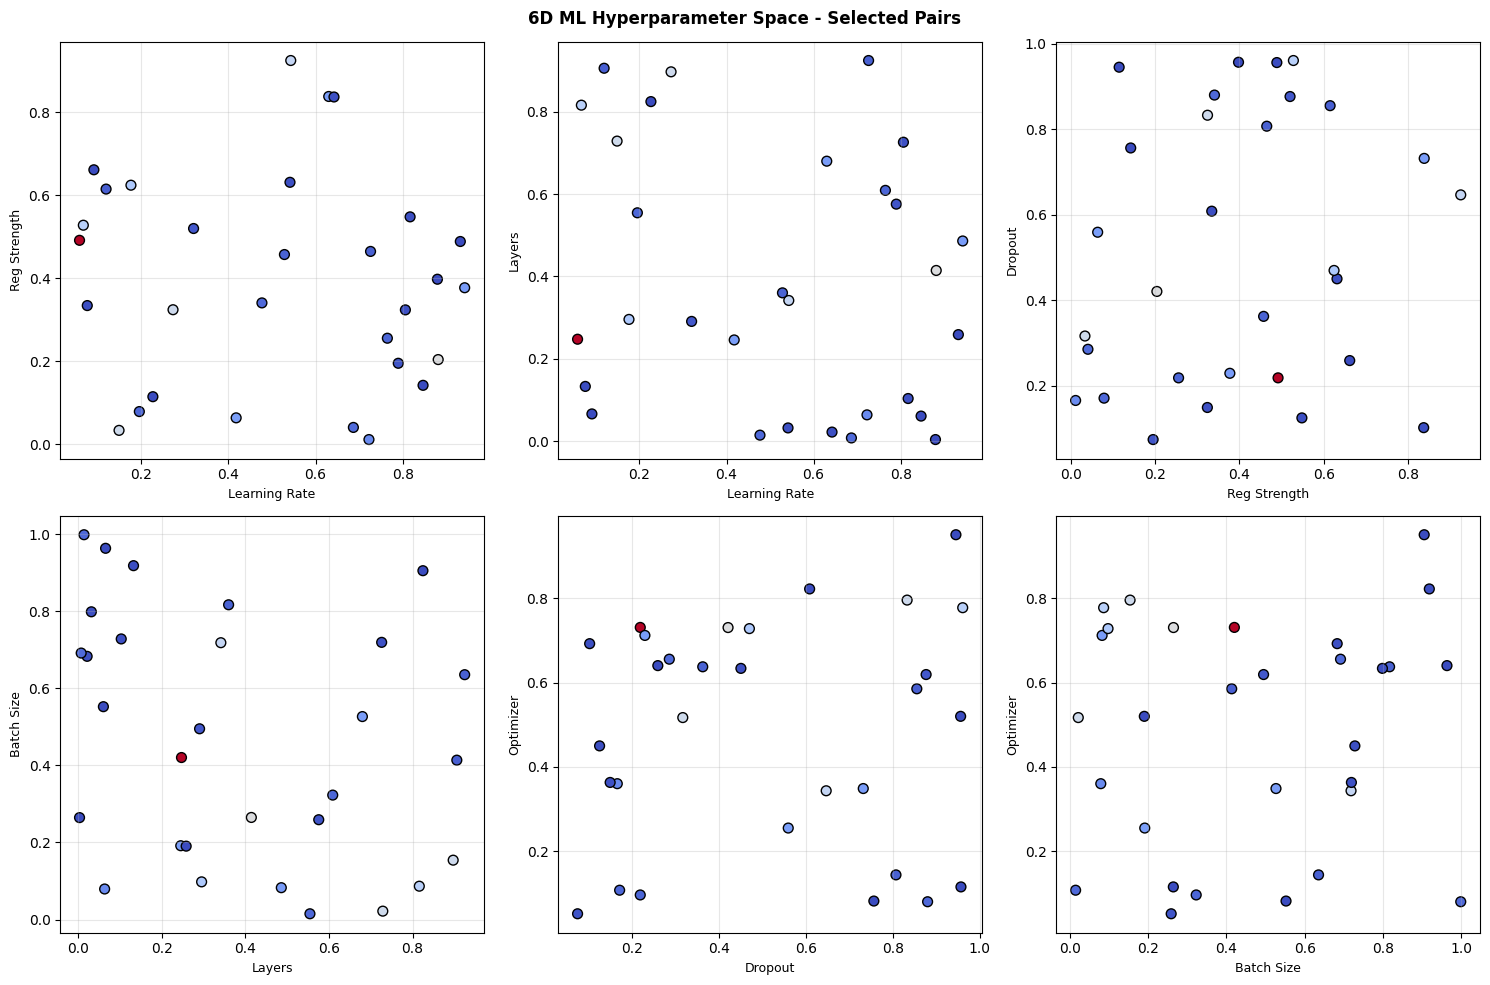

In [3]:
# Visualize subset of pairs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
pairs = [(0,1), (0,2), (1,3), (2,4), (3,5), (4,5)]
for idx, (i, j) in enumerate(pairs):
    axes[idx].scatter(X_init[:, i], X_init[:, j], c=y_init, cmap='coolwarm', edgecolors='black', s=50)
    axes[idx].set_xlabel(hyperparam_names[i], fontsize=9)
    axes[idx].set_ylabel(hyperparam_names[j], fontsize=9)
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('6D ML Hyperparameter Space - Selected Pairs', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: Hyperparameters & Optimization

**6D Space:** Restarts: 25, Raw: 3072 (higher dimensional requires more thorough search)

In [ ]:
# All inputs must be in range [0, 0.999999] per submission requirements
N_DIM = X_init.shape[1]
BOUNDS = torch.tensor([[0.0] * N_DIM, [0.999999] * N_DIM], dtype=torch.float64)
NUM_RESTARTS, RAW_SAMPLES = 25, 3072
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
fit_gpytorch_mll(mll)
EI = ExpectedImprovement(gp_model, best_f=y_train.max().item())
candidate, acq_value = optimize_acqf(EI, bounds=BOUNDS, q=1, num_restarts=NUM_RESTARTS, raw_samples=RAW_SAMPLES)
next_point = candidate.detach().numpy()[0]
print(f"✓ Next config: {dict(zip(hyperparam_names, next_point))}")

✓ Next config: {'Learning Rate': np.float64(-0.04210445802861476), 'Reg Strength': np.float64(0.38668013791053085), 'Layers': np.float64(0.3221710671265078), 'Dropout': np.float64(0.18238899147694418), 'Batch Size': np.float64(0.37411422532535304), 'Optimizer': np.float64(0.7644557627339268)}


### Step 4: Analysis & Visualization

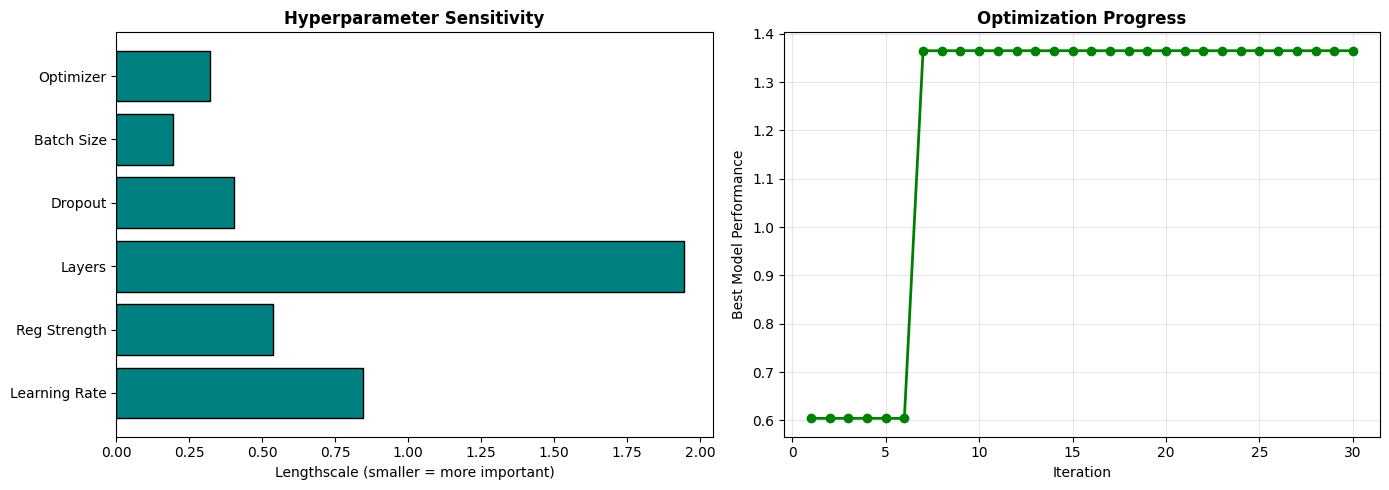

Next submission: [-0.04210446  0.38668014  0.32217107  0.18238899  0.37411423  0.76445576]


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Safe lengthscale access (kernel structure may vary)
if hasattr(gp_model.covar_module, 'base_kernel'):
    ls = gp_model.covar_module.base_kernel.lengthscale.detach().numpy()[0]
else:
    ls = gp_model.covar_module.lengthscale.detach().numpy()[0]

ax1.barh(hyperparam_names, ls, color='teal', edgecolor='black')
ax1.set_xlabel('Lengthscale (smaller = more important)')
ax1.set_title('Hyperparameter Sensitivity', fontweight='bold')

best_so_far = np.maximum.accumulate(y_init)
ax2.plot(range(1, len(best_so_far)+1), best_so_far, 'g-o', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Best Model Performance')
ax2.set_title('Optimization Progress', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Next submission: {next_point}")

### Visualize Expected Improvement

For higher-dimensional spaces, we visualize 1D slices of the acquisition function.
Each plot shows how EI changes along one dimension while others are fixed at the proposed point.

In [ ]:
# 1D marginal plots of Expected Improvement
n_points = 100
n_dims = len(next_point)

fig, axes = plt.subplots(1, n_dims, figsize=(4*n_dims, 4))
if n_dims == 1:
    axes = [axes]

for dim in range(n_dims):
    # Create points varying along this dimension
    X_marginal = np.tile(next_point, (n_points, 1))
    X_marginal[:, dim] = np.linspace(0, 0.999999, n_points)
    X_marginal_torch = torch.tensor(X_marginal, dtype=torch.float64)
    
    # Compute EI at each point
    with torch.no_grad():
        ei_values = EI(X_marginal_torch.unsqueeze(1)).numpy()
    
    # Plot
    axes[dim].plot(X_marginal[:, dim], ei_values, 'b-', linewidth=2)
    axes[dim].axvline(next_point[dim], color='r', linestyle='--', linewidth=2, label='Proposed')
    axes[dim].set_xlabel(f'x{dim+1}', fontsize=12)
    axes[dim].set_ylabel('Expected Improvement' if dim == 0 else '', fontsize=12)
    axes[dim].set_title(f'EI along dim {dim+1}', fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3)
    if dim == 0:
        axes[dim].legend()

plt.suptitle('Expected Improvement - 1D Marginals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red dashed lines show the proposed next point coordinates.")
print(f"EI is maximized when considering all dimensions jointly.")

### Step 5: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 0.999999]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 0.999999]."""
    clamped = [max(0.0, min(0.999999, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(0.999999, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 7")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")